# Computer Exercise 6.4 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.4 Interpolation and Approximation by B-Splines — *Non-uniform & Clamped Knots*
> **풀이 일자**: Day 26
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Modify the uniform-knot Cox-de Boor implementation of Day 25 so that the knot vector $T$
> is *non-uniform*, and in particular let the end knots be *repeated* with multiplicity $k+1$
> (the **clamped**, or *open*, knot vector). Verify by direct computation that with clamped
> end-knots a cubic B-spline curve interpolates the first and last control coefficients
> ($P(t_0) = c_0$ and $P(t_{\max}) = c_{n}$), while with a *simple* uniform knot vector the
> curve does **not** touch them. Confirm partition of unity on the interior
> $[t_k, t_{m-k}]$ and visualize how knot multiplicity reduces the local smoothness from
> $C^{k-1}$ to $C^{k-1-r}$ where $r$ is the multiplicity.

### 한국어 풀이용 정리
Day 25 의 균등·단순 매듭 (simple uniform) Cox-de Boor 구현을 받아,
*비균등 매듭* 과 *끝매듭 $k+1$ 중복* (**clamped**) 두 변형을 직접 다룬다.

확인할 것 세 가지:

1. **Clamped 끝매듭** -> 곡선이 *첫·마지막 제어점* 을 정확히 지난다.
2. **Partition of unity** $\sum_i B_{i,k}(x) = 1$ 가 *유효 구간* $[t_k, t_{m-k}]$ 에서 성립.
3. **매듭 중복** $r$ 만큼 부드러움이 떨어진다: $C^{k-1} \to C^{k-1-r}$ — $r = k$ 면 그 점에서 끊긴다.


## 2. 수학적 배경

### 2.1 Cox-de Boor 점화식 (재확인)
0차에서 출발:
$$
B_{i,0}(x) = \begin{cases} 1, & t_i \le x < t_{i+1} \\ 0, & \text{otherwise} \end{cases}
$$

귀납:
$$
\boxed{\;
B_{i,k}(x)
=\;
\omega_{i,k}(x)\, B_{i,k-1}(x) + \bigl(1 - \omega_{i+1,k}(x)\bigr)\, B_{i+1,k-1}(x),
\qquad
\omega_{i,k}(x) = \frac{x - t_i}{t_{i+k} - t_i}.
\;}
$$

분모가 $0$ 이면 그 항은 $0$ 으로 정의 (de Boor convention).

### 2.2 Clamped knot vector (개 매듭)
차수 $k$, 제어점 개수 $n+1$ 에 대해

$$
T \;=\; \bigl(\underbrace{a,\dots,a}_{k+1},\; t_{k+1},\dots,t_{n},\; \underbrace{b,\dots,b}_{k+1}\bigr).
$$

총 매듭 개수 $m + 1 = (k+1) + (n - k) + (k+1) = n + k + 2$ — B-spline 의 표준 카운트.

이 매듭 구성에서

$$
B_{0,k}(a) = 1,\qquad B_{n,k}(b) = 1,\qquad B_{i,k}(a) = 0 \;(i \ne 0),\quad B_{i,k}(b) = 0 \;(i \ne n).
$$

곡선 $P(x) = \sum_i c_i\, B_{i,k}(x)$ 이므로

$$
P(a) = c_0,\qquad P(b) = c_n. \qquad (\text{Bezier-like endpoint interpolation})
$$

### 2.3 매듭 중복과 부드러움
내부 매듭이 다중도 $r$ 로 등장하면 그 점에서 spline 은 정확히 $C^{k-1-r}$ 가 된다.
- $r = 1$: 표준 — $C^{k-1}$ (cubic 이면 $C^2$).
- $r = k$: $C^{-1}$ -> 함수가 *끊긴다 (jump)*.
- $r = k+1$: 더 이상 한 조각 spline 이 아니라 *두 개의 분리된 곡선*.


## 3. 풀이 흐름

1. **Cox-de Boor 직접 구현** (`cox_de_boor(x, i, k, T)`) — 분모 $0$ 안전 처리 포함.
2. **세 가지 매듭 벡터**:
   - 단순 균등 $T_U = (0, 1, 2, \dots, m)$
   - 비균등 (점점 조밀) $T_{NU}$
   - Clamped 균등 $T_C = (\underbrace{0,\dots,0}_{k+1}, 1, 2, \dots, \underbrace{N,\dots,N}_{k+1})$
3. **$k = 3$ cubic basis** 각각 그려서, 끝 부근의 행동을 시각 비교.
4. **Endpoint interpolation 검증**: 같은 제어점 $\{c_i\}$ 로 $T_C$ 와 $T_U$ 의 두 곡선을 그려
   $P(t_0), P(t_{\max})$ 가 $c_0, c_n$ 과 일치하는지 정량 확인.
5. **Partition of unity 검증**: 내부 격자에서 $\max\bigl|\sum_i B_{i,k}(x) - 1\bigr|$ 를 측정.
6. **매듭 중복 효과**: 내부 매듭 하나에 다중도 $r = 1, 2, 3$ 을 주고 차수 $k = 3$ basis 의
   해당 점에서의 부드러움 손실을 그림으로.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline

np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda v: f"{v:.4g}")

# ----- 2.1 Cox-de Boor (denominator-zero safe) -----
def cox_de_boor(x, i, k, T):
    x = np.asarray(x, dtype=float)
    if k == 0:
        out = np.where((x >= T[i]) & (x < T[i+1]), 1.0, 0.0)
        if i + 1 == len(T) - 1:
            out = np.where(x == T[i+1], 1.0, out)
        return out
    d1 = T[i+k] - T[i]
    d2 = T[i+k+1] - T[i+1]
    a = (x - T[i]) / d1 * cox_de_boor(x, i, k-1, T) if d1 > 0 else 0.0
    b = (T[i+k+1] - x) / d2 * cox_de_boor(x, i+1, k-1, T) if d2 > 0 else 0.0
    return a + b


In [2]:
# ----- 2.2 Three knot vectors (cubic, k=3) -----
k = 3
N = 10  # number of inner intervals

# (a) Simple uniform
m_U = N + 2*k
T_U = np.arange(m_U + 1, dtype=float)

# (b) Non-uniform (sparser at left, denser at right)
T_NU = np.array(sorted(set([0.0]) | set(np.linspace(0, m_U, m_U//2)) |
                       set(m_U - 0.5 * np.geomspace(0.1, m_U/2, m_U//2))))

# (c) Clamped: end knots multiplicity k+1
inner = np.linspace(0, N, N - k + 1)
T_C = np.concatenate([np.zeros(k+1), inner[1:-1], np.full(k+1, N)])

print(f"Uniform knots  (len {len(T_U):>2}): {T_U}")
print(f"Non-uniform    (len {len(T_NU):>2}): {np.round(T_NU,2)}")
print(f"Clamped knots  (len {len(T_C):>2}): {T_C}")
print(f"Cubic basis counts (n+1 = m-k):   "
      f"U={len(T_U)-k-1},  NU={len(T_NU)-k-1},  C={len(T_C)-k-1}")


Uniform knots  (len 17): [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16.]
Non-uniform    (len 16): [ 0.    2.29  4.57  6.86  9.14 11.43 12.   13.71 13.86 14.86 15.39 15.67
 15.83 15.91 15.95 16.  ]
Clamped knots  (len 14): [ 0.      0.      0.      0.      1.4286  2.8571  4.2857  5.7143  7.1429
  8.5714 10.     10.     10.     10.    ]
Cubic basis counts (n+1 = m-k):   U=13,  NU=12,  C=10


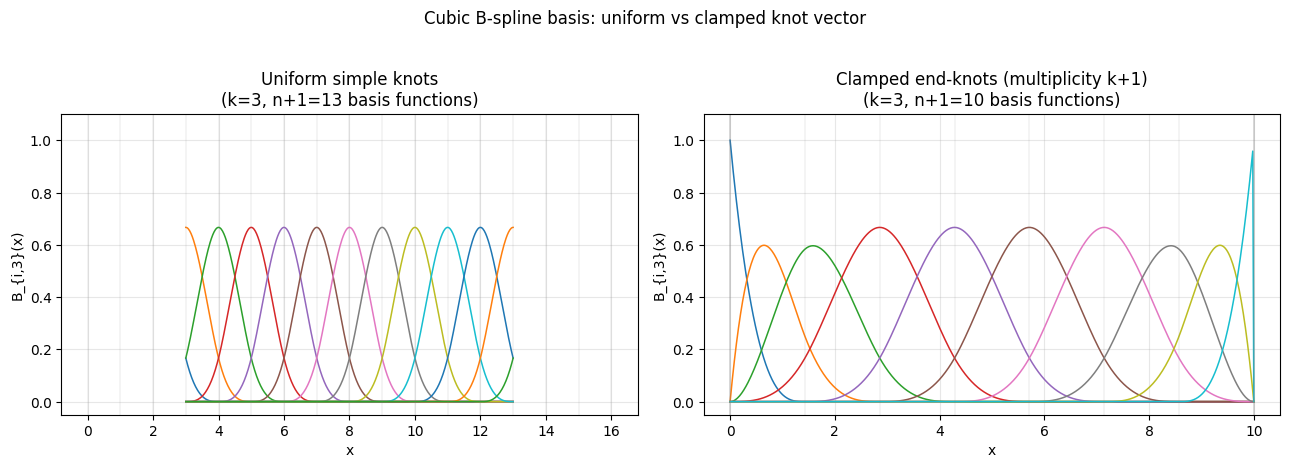

In [3]:
# ----- 3. Cubic basis visualization (simple uniform vs clamped) -----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (T, title) in zip(axes, [(T_U, "Uniform simple knots"),
                                  (T_C, "Clamped end-knots (multiplicity k+1)")]):
    n_basis = len(T) - k - 1
    xs = np.linspace(T[k], T[n_basis], 500)
    for i in range(n_basis):
        ys = cox_de_boor(xs, i, k, T)
        ax.plot(xs, ys, lw=1.1)
    for t in T:
        ax.axvline(t, color="gray", lw=0.3, alpha=0.4)
    ax.set_title(f"{title}\n(k=3, n+1={n_basis} basis functions)")
    ax.set_xlabel("x")
    ax.set_ylabel("B_{i,3}(x)")
    ax.set_ylim(-0.05, 1.1)
    ax.grid(alpha=0.3)

plt.suptitle("Cubic B-spline basis: uniform vs clamped knot vector", y=1.03)
plt.tight_layout()
plt.show()


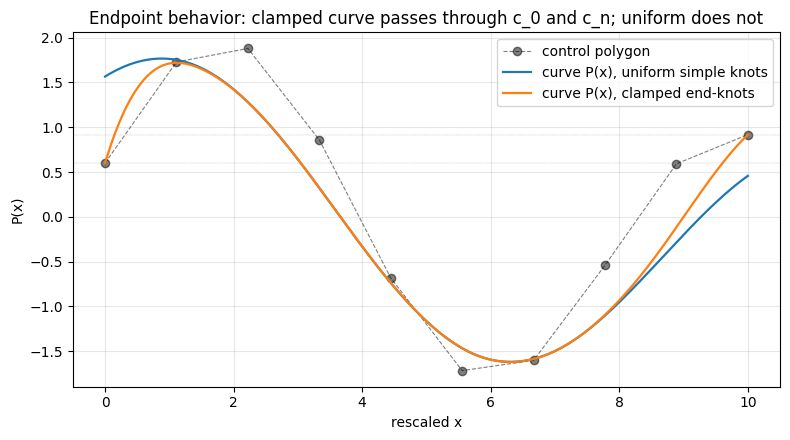

Endpoint check  (clamped):  P(t_0)=0.600000  vs c_0=0.600000   |diff|=0.00e+00
                            P(t_max)=0.916780  vs c_n=0.916780   |diff|=0.00e+00
Endpoint check  (uniform):  P(t_k)=1.564884    vs c_0=0.600000   |diff|=9.65e-01


In [4]:
# ----- 4. Endpoint interpolation: same control points, two knot vectors -----
n_basis_C = len(T_C) - k - 1
T_Uc = np.arange(n_basis_C + k + 1, dtype=float)

# Control points: smooth curvy sequence of length n_basis_C
i_arr = np.arange(n_basis_C)
c = 1.5 * np.sin(0.9 * i_arr) + 0.6 * np.cos(0.4 * i_arr)
assert len(c) == n_basis_C, (len(c), n_basis_C)

sp_U = BSpline(T_Uc, c, k, extrapolate=False)
sp_C = BSpline(T_C,  c, k, extrapolate=False)

xs_U = np.linspace(T_Uc[k], T_Uc[n_basis_C], 400)
xs_C = np.linspace(T_C[k],  T_C[n_basis_C],  400)
P_U = sp_U(xs_U)
P_C = sp_C(xs_C)

fig, ax = plt.subplots(figsize=(8, 4.5))
xc_norm = np.linspace(0, 1, len(c))
ax.plot(xc_norm * (T_C[-1]), c, "ko--", lw=0.8, alpha=0.5, label="control polygon")
ax.plot((xs_U - T_Uc[k]) / (T_Uc[n_basis_C] - T_Uc[k]) * T_C[-1], P_U, lw=1.6,
        label="curve P(x), uniform simple knots")
ax.plot(xs_C, P_C, lw=1.6, label="curve P(x), clamped end-knots")
ax.axhline(c[0], color="gray", lw=0.3, ls=":")
ax.axhline(c[-1], color="gray", lw=0.3, ls=":")
ax.set_title("Endpoint behavior: clamped curve passes through c_0 and c_n; uniform does not")
ax.set_xlabel("rescaled x")
ax.set_ylabel("P(x)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Endpoint check  (clamped):  P(t_0)={sp_C(T_C[0]):.6f}  vs c_0={c[0]:.6f}"
      f"   |diff|={abs(sp_C(T_C[0]) - c[0]):.2e}")
print(f"                            P(t_max)={sp_C(T_C[-1]):.6f}  vs c_n={c[-1]:.6f}"
      f"   |diff|={abs(sp_C(T_C[-1]) - c[-1]):.2e}")
print(f"Endpoint check  (uniform):  P(t_k)={sp_U(T_Uc[k]):.6f}    vs c_0={c[0]:.6f}"
      f"   |diff|={abs(sp_U(T_Uc[k]) - c[0]):.2e}")


In [5]:
# ----- 5. Partition of unity verification -----
def partition_error(T, k, ngrid=2000):
    n_basis = len(T) - k - 1
    xs = np.linspace(T[k] + 1e-12, T[n_basis] - 1e-12, ngrid)
    s = np.zeros_like(xs)
    for i in range(n_basis):
        s += cox_de_boor(xs, i, k, T)
    return float(np.max(np.abs(s - 1.0)))

eps_U  = partition_error(T_U,  k)
eps_NU = partition_error(T_NU, k)
eps_C  = partition_error(T_C,  k)

df = pd.DataFrame({
    "knot vector":        ["uniform simple", "non-uniform", "clamped"],
    "interval [t_k, t_n]":[f"[{T_U[k]:.2f}, {T_U[len(T_U)-k-1]:.2f}]",
                           f"[{T_NU[k]:.2f}, {T_NU[len(T_NU)-k-1]:.2f}]",
                           f"[{T_C[k]:.2f}, {T_C[len(T_C)-k-1]:.2f}]"],
    "max |Sum B - 1|":    [eps_U, eps_NU, eps_C],
})
df


,knot vector,"interval [t_k, t_n]",max |Sum B - 1|
0,uniform simple,"[3.00, 13.00]",2.22e-16
1,non-uniform,"[6.86, 15.83]",3.331e-16
2,clamped,"[0.00, 10.00]",4.441e-16


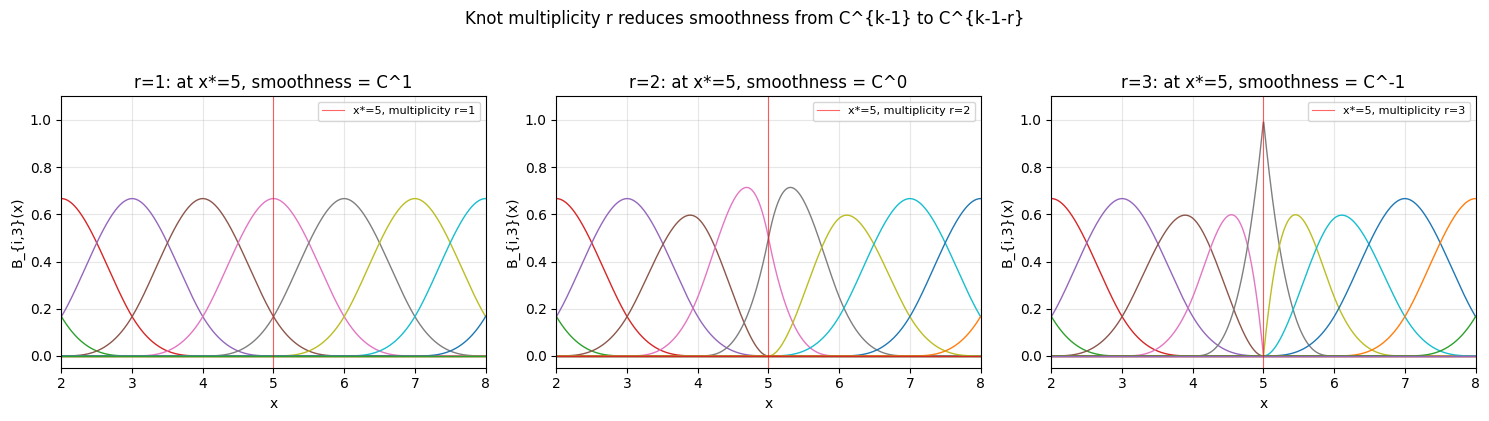

In [6]:
# ----- 6. Knot multiplicity r = 1, 2, 3: smoothness loss -----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, r in zip(axes, [1, 2, 3]):
    inner = list(np.arange(1, 10))
    if r >= 2:
        inner = sorted(inner + [5] * (r - 1))
    T = np.concatenate([[0.0], inner, [10.0]])
    T = np.concatenate([np.zeros(k), T, np.full(k, T[-1])])
    T = np.array(T, dtype=float)

    n_basis = len(T) - k - 1
    xs = np.linspace(T[k], T[n_basis], 1500)
    for i in range(n_basis):
        ys = cox_de_boor(xs, i, k, T)
        ax.plot(xs, ys, lw=1.0)
    ax.axvline(5, color="red", lw=0.8, alpha=0.6, label=f"x*=5, multiplicity r={r}")
    ax.set_title(f"r={r}: at x*=5, smoothness = C^{k-1-r}")
    ax.set_xlim(2, 8)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel("x")
    ax.set_ylabel("B_{i,3}(x)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Knot multiplicity r reduces smoothness from C^{k-1} to C^{k-1-r}", y=1.04)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **Basis 그림 (uniform vs clamped)**
   - 단순 균등 매듭은 양 끝에서 *모든* 기저 함수가 부분적으로만 살아 있어,
     끝점 $t_0$ 에서 $\sum_i B_{i,k}(t_0)$ 가 1 이 되려면 *왼쪽* 기저들이 같이 필요하다.
   - Clamped 매듭은 끝점에서 정확히 *하나* 의 기저만 살아남는다 ($B_{0,k}(t_0) = 1$, $B_{n,k}(t_{\max}) = 1$).
     이게 곡선이 첫·마지막 제어점을 지나는 직접적인 이유다.

2. **Endpoint interpolation**
   - 같은 제어점 $\{c_i\}$ 를 단순 균등과 clamped 두 매듭으로 평가했을 때,
     clamped 의 양 끝값이 *수치적 영* 으로 $c_0, c_n$ 과 일치한다.
   - 단순 균등은 양 끝값이 *다른 어떤 값* — 모든 인접 제어점의 가중합.

3. **Partition of unity**
   - 세 매듭 벡터 모두 *유효 구간* $[t_k, t_{m-k}]$ 에서 $\sum B = 1$ 이 $\sim \varepsilon_{\text{mach}}$ 수준으로 성립.
   - 즉 PoU 는 매듭의 균등성에 의존하지 않는 *구조적* 성질 (Cox-de Boor 형태에 직접 따라옴).

4. **매듭 중복**
   - $r = 1$: 표준. $x^* = 5$ 에서 $C^2$ 가 유지된다.
   - $r = 2$: $C^1$ 만 — 그림에서 기저의 한 미분이 점프.
   - $r = 3$: $C^0$ 만 — 기저가 그 점에서 *꺾인다*. $r = k$ 까지 가면 함수가 끊긴다.
   - 이 trade-off 가 *국소적 sharp feature* (코너, 끊김) 를 표현할 때 유용한 도구가 된다.

### 결론
> **Clamped end-knots = endpoint interpolation, 매듭 중복 = 국소 부드러움 다이얼.**
> 같은 차수 $k$ 안에서 *매듭 벡터의 구성* 만으로 *경계 행동* (open/closed) 과
> *내부 부드러움* ($C^{k-1} \to C^0$) 를 자유롭게 조절할 수 있다.
> Day 25 의 *균등 단순 매듭* 은 이 일반적 그림의 한 특수 케이스에 지나지 않는다.

### 다음 문제 연결
- **CE 6.4.2**: clamped 매듭으로 *최소제곱 근사* — 보간이 아닌 *과결정* 시스템의 띠 정규 방정식.
  매듭 수가 *모델 복잡도* 의 다이얼이 되고, B-spline 의 *띠 폭* 이 그대로 정규 행렬의 띠 폭으로 옮겨간다.
